# Predictive Analysis and Explainable AI (XAI)


In [146]:
!pip install shap xgboost lightgbm seaborn matplotlib pandas numpy scikit-learn

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import shap

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')


## Load Data

We load both artists and tracks.

In [148]:
try:
    df_artists = pd.read_csv('../dataset/artists.csv', sep=None, index_col=0, engine='python', encoding='utf-8')
    df_tracks = pd.read_csv('../dataset/cleaned_tracks.csv')
    print(f"Artists: {df_artists.shape}")
    print(f"Tracks: {df_tracks.shape}")
except Exception as e:
    print("Error loading data. Ensure paths are correct.", e)


Artists: (104, 13)
Tracks: (11158, 45)


## Data Cleaning & Imputation (Artists dataset)

Instead of dropping `active_start`, we impute it using the Tracks data (earliest song year per artist).


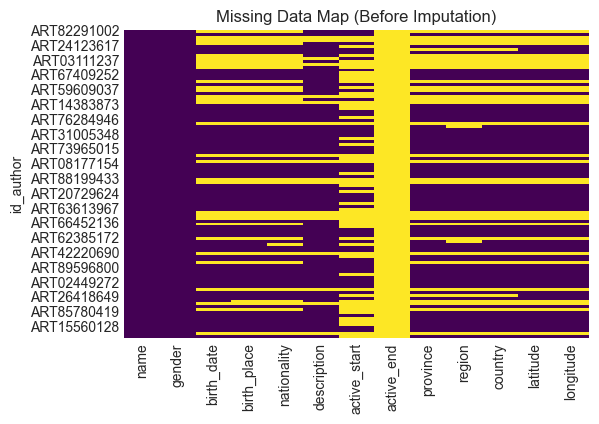

Imputation complete. 'active_start_final' and 'gender_code' ready.
active_start_final    0
gender_code           0
dtype: int64


In [149]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_artists.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Map (Before Imputation)')
plt.show()

cols_to_drop_artists = [
    'birth_date', 'birth_place', 'nationality',
    'description', 'active_end', 'province',
    'country', 'latitude', 'longitude'
]
df_artists = df_artists.drop(columns=[c for c in cols_to_drop_artists if c in df_artists.columns])

artist_min_year = df_tracks.groupby('id_artist')['year'].min()

df_artists['min_track_year'] = df_artists.index.map(artist_min_year)

df_artists['active_start_dt'] = pd.to_datetime(df_artists['active_start'], errors='coerce')
df_artists['active_start_year'] = df_artists['active_start_dt'].dt.year

df_artists['active_start_final'] = df_artists['active_start_year'].fillna(df_artists['min_track_year'])

median_year = df_artists['active_start_final'].median()
df_artists['active_start_final'] = df_artists['active_start_final'].fillna(median_year)

# Encode Gender (M=0, F=1, Missing=Mode)
df_artists['gender'] = df_artists['gender'].fillna('M')
le_gender = LabelEncoder()
df_artists['gender_code'] = le_gender.fit_transform(df_artists['gender'].astype(str))

print("Imputation complete. 'active_start_final' and 'gender_code' ready.")
print(df_artists[['active_start_final', 'gender_code']].isnull().sum())


## Data Visualization: Imputation Results
The distribution of `active_start` after imputation.


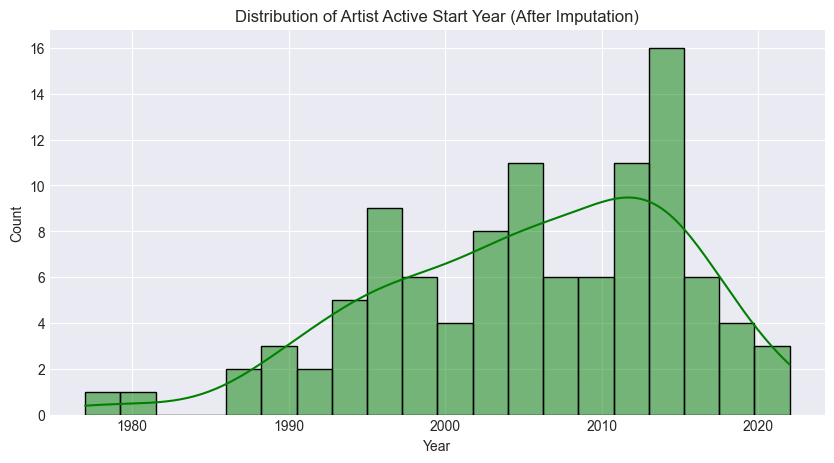

In [150]:
plt.figure(figsize=(10, 5))
sns.histplot(df_artists['active_start_final'], bins=20, kde=True, color='green')
plt.title('Distribution of Artist Active Start Year (After Imputation)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


## NLP Feature Engineering (TF-IDF)

We extract top 50 characteristic words from lyrics. This captures dialect/slang differences between regions.


In [151]:
df_tracks['lyrics'] = df_tracks['lyrics'].fillna('')

# TF-IDF Vectorizer
# we make max_features=50 ensures we don't overfit, capturing common slang
tfidf = TfidfVectorizer(max_features=80, stop_words='english')

print("Fitting TF-IDF on lyrics...")
tfidf_matrix = tfidf.fit_transform(df_tracks['lyrics'])

tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])]
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df_tracks.index)

df_tracks = pd.concat([df_tracks, df_tfidf], axis=1)

print(f"Added {len(tfidf_cols)} NLP features.")


Fitting TF-IDF on lyrics...
Added 80 NLP features.


## Merge & Macro-Zone Definition

We use the specific Balance Macro-Zones to reduce the models being biased.


Macro-zone distribution:
macro_zone
Center_South_Islands    3575
Lombardia               2658
North_Center            1783
Name: count, dtype: int64


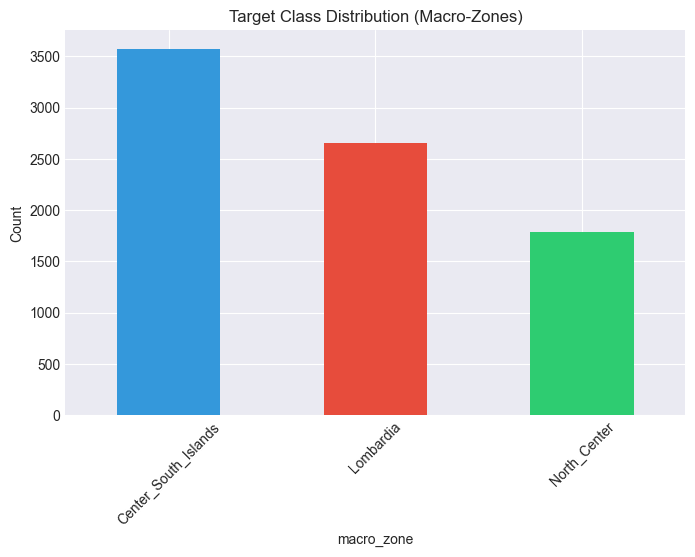

In [152]:
df_merged = pd.merge(df_tracks, df_artists, left_on='id_artist', right_index=True, how='inner')

macro_zone_mapping = {
    'Lombardia': 'Lombardia',
    'Piemonte': 'North_Center', 'Veneto': 'North_Center', 'Liguria': 'North_Center',
    'Emilia-Romagna': 'North_Center', 'Trentino-Alto Adige': 'North_Center', 'Toscana': 'North_Center', 'Marche': 'North_Center', 'Umbria': 'North_Center',
    'Lazio': 'Center_South_Islands', 'Campania': 'Center_South_Islands', 'Puglia': 'Center_South_Islands', 'Calabria': 'Center_South_Islands',
    'Sicilia': 'Center_South_Islands', 'Sardegna': 'Center_South_Islands'
}
df_merged['macro_zone'] = df_merged['region'].map(macro_zone_mapping)

df_merged = df_merged.dropna(subset=['macro_zone'])

print("Macro-zone distribution:")
print(df_merged['macro_zone'].value_counts())

plt.figure(figsize=(8, 5))
df_merged['macro_zone'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'])
plt.title('Target Class Distribution (Macro-Zones)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


## Model Training & Comparison

We will train and compare 3 models:
1. **Random Forest**: Good baseline, handles non-linearities well.
2. **XGBoost**: Gradient boosting, often high performance.
3. **LightGBM**: Fast, efficient gradient boosting, great with many features.


In [153]:
target_col = 'macro_zone'
y = df_merged[target_col]

metadata_cols = [
    'id_artist', 'id_track', 'name', 'id_album', 'track_id',
    'lyrics', 'description', 'birth_place', 'nationality', 'gender', 
    'region', 'province', 'country', 'macro_zone', 'latitude', 'longitude',
    'active_start', 'active_end', 'birth_date', 'active_start_dt',
    'active_start_year', 'min_track_year',
    'month', 'day', 'popularity', 'stats_pageviews', 'modified_popularity',
    'track_number', 'disc_number', 'swear_IT_words', 'swear_EN_words'
]

X = df_merged.select_dtypes(include=[np.number])
cols_to_drop = [c for c in metadata_cols if c in X.columns]
X = X.drop(columns=cols_to_drop)
X = X.fillna(0)
print(f"Selected {X.shape[1]} features dynamically.")
print(f"Feature Examples: {list(X.columns)}...")


Selected 102 features dynamically.
Feature Examples: ['swear_IT', 'swear_EN', 'year', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'duration_ms', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21', 'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27', 'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33', 'tfidf_34', 'tfidf_35', 'tfidf_36', 'tfidf_37', 'tfidf_38', 'tfidf_39', 'tfidf_40', 'tfidf_41', 'tfidf_42', 'tfidf_43', 'tfidf_44', 'tfidf_45', 'tfidf_46', 'tfidf_47', 'tfidf_48', 'tfidf_49', 'tfidf_50', 'tfidf_51', 'tfidf_52', 'tfidf_53', 'tfidf_54', 'tfidf_55', 'tfidf_56', 'tfidf_57', 

In [154]:
# Encode Target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Classes: {le_target.classes_}")


# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

X_train = np.ascontiguousarray(X_train)
X_test = np.ascontiguousarray(X_test)

Classes: ['Center_South_Islands' 'Lombardia' 'North_Center']


### Train Models


In [155]:
# models = {

#     'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1),
#     'XGBoost': xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, reg_alpha=1, reg_lambda=1, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
#     'LightGBM': lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=20, reg_alpha=1, reg_lambda=1, random_state=42, verbose=-1)
# }

# results = {}
# trained_models = {}

# for name, model in models.items():
#     print(f"Training {name}...")
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
    
#     f1 = f1_score(y_test, y_pred, average='macro')
#     results[name] = f1
#     trained_models[name] = model
    
#     print(f"{name} F1-Macro: {f1:.4f}")



from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grids (The "Search Space")
param_grids = {
    'RandomForest': {
        'n_estimators': [200],
        'max_depth': [5, 8, 12],       
        'min_samples_leaf': [2, 4, 6]  
    },
    'XGBoost': {
        'n_estimators': [200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],           
        'reg_alpha': [0.1, 1.0],        
        'reg_lambda': [0.1, 1.0]        
    },
    'LightGBM': {
        'n_estimators': [200],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [30, 50],       
        'reg_alpha': [0.0, 0.1],
        'reg_lambda': [0.0, 0.1]
    }
}

base_models = {
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1)
}

models = {} 
results = {}

print("Starting Hyperparameter Tuning")

for name, model in base_models.items():
    print(f"\n Hyper parameter Tuning {name} ")
    grid = GridSearchCV(model, param_grids[name], cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)
    
    print(f"Best Params: {grid.best_params_}")
    print(f"Best CV Score: {grid.best_score_:.4f}")
    
    models[name] = grid.best_estimator_
    
    y_pred = models[name].predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = f1
    print(f"Test Set F1: {f1:.4f}")

print("\nTuning Complete. ")


Starting Hyperparameter Tuning

 Hyper parameter Tuning RandomForest 
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Params: {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 200}
Best CV Score: 0.6524
Test Set F1: 0.6872

 Hyper parameter Tuning XGBoost 
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:31:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:31:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:31:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:31:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iterati

Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 1.0, 'reg_lambda': 0.1}
Best CV Score: 0.8384
Test Set F1: 0.8464

 Hyper parameter Tuning LightGBM 
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

Best Params: {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 50, 'reg_alpha': 0.0, 'reg_lambda': 0.1}
Best CV Score: 0.8588
Test Set F1: 0.8817

Tuning Complete.


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Comparison Visualization


/var/folders/29/j2385crd6f5dyk4l3185qktm0000gn/T/ipykernel_89873/2410872305.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


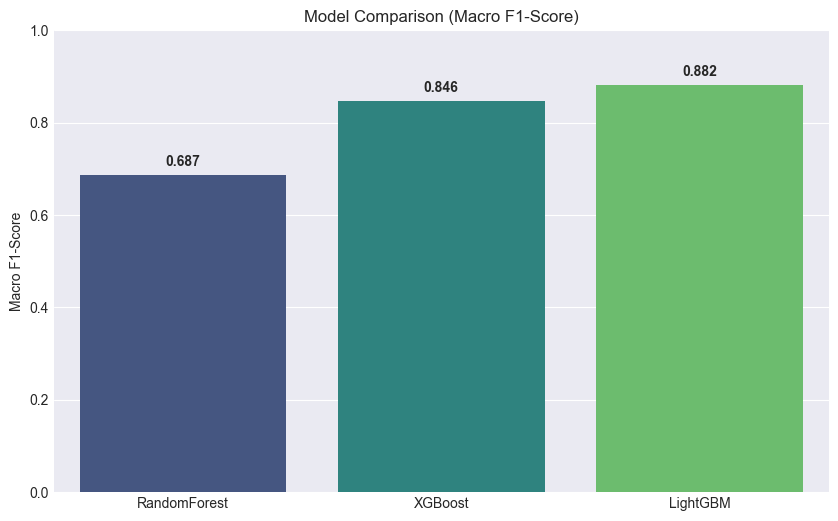


Best Model: LightGBM with F1-Macro: 0.8817


In [156]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Comparison (Macro F1-Score)')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\nBest Model: {best_model_name} with F1-Macro: {results[best_model_name]:.4f}")


Generating curve for RandomForest...
Generating curve for XGBoost...


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:35:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


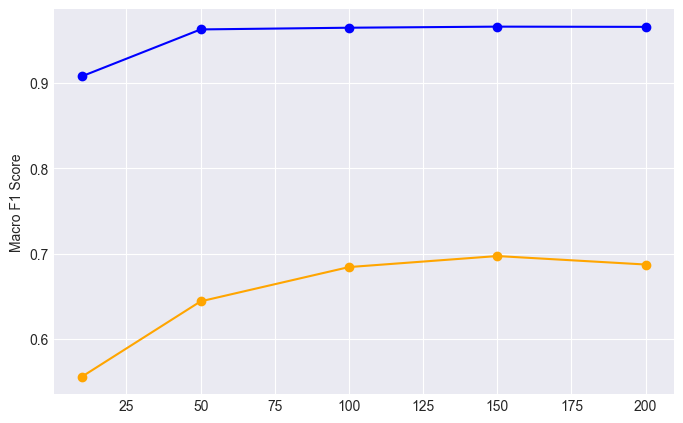

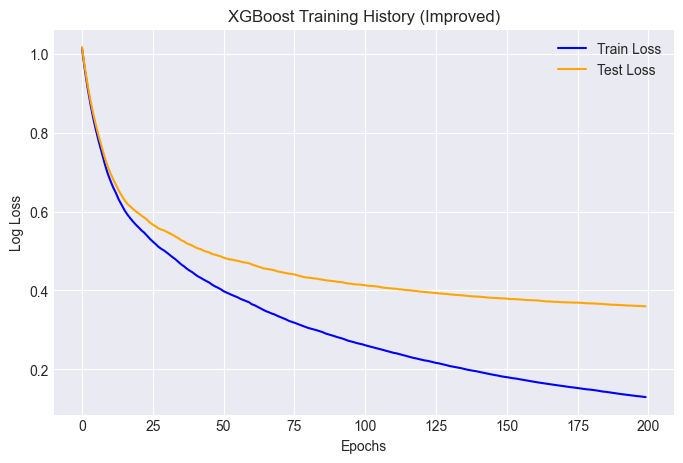

Generating curve for LightGBM...


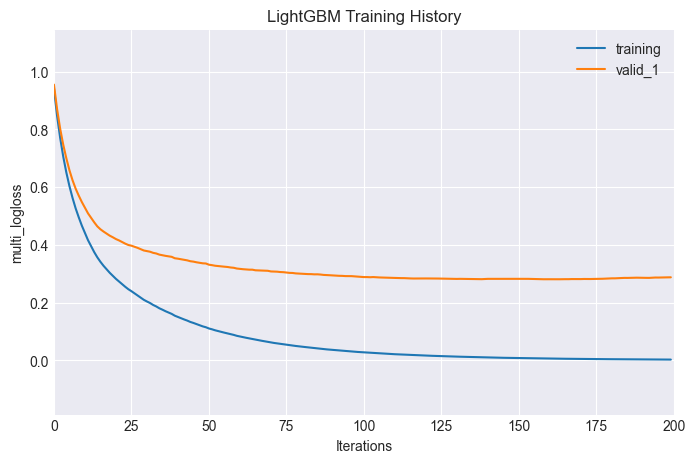

In [157]:
for name, model in models.items():
    plt.figure(figsize=(8, 5)) 
    print(f"Generating curve for {name}...")
    
    if name == 'XGBoost':
        model_curve = xgb.XGBClassifier(**model.get_params())
        eval_set = [(X_train, y_train), (X_test, y_test)]
        model_curve.fit(X_train, y_train, eval_set=eval_set, verbose=False)
        results_curve = model_curve.evals_result()
        
        epochs = len(results_curve['validation_0']['mlogloss'])
        x_axis = range(0, epochs)
        
        plt.plot(x_axis, results_curve['validation_0']['mlogloss'], label='Train Loss', color='blue')
        plt.plot(x_axis, results_curve['validation_1']['mlogloss'], label='Test Loss', color='orange')
        plt.ylabel('Log Loss')
        plt.xlabel('Epochs')
        plt.title(f'XGBoost Training History (Improved)')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    elif name == 'LightGBM':
        model_curve = lgb.LGBMClassifier(**model.get_params())
        eval_set = [(X_train, y_train), (X_test, y_test)]
        callbacks = [lgb.log_evaluation(period=-1)]
        model_curve.fit(X_train, y_train, eval_set=eval_set, eval_metric='multi_logloss', callbacks=callbacks)
        
        lgb.plot_metric(model_curve, metric='multi_logloss', ax=plt.gca())
        plt.title(f'LightGBM Training History')
        plt.grid(True)
        plt.show()
        
    elif name == 'RandomForest':
        n_estimators_range = [10, 50, 100, 150, 200]
        train_scores = []
        test_scores = []
        
        base_params = model.get_params()
        
        for n in n_estimators_range:
            current_params = base_params.copy()
            current_params['n_estimators'] = n
            
            rf = RandomForestClassifier(**current_params)
            rf.fit(X_train, y_train)
            train_scores.append(f1_score(y_train, rf.predict(X_train), average='macro'))
            test_scores.append(f1_score(y_test, rf.predict(X_test), average='macro'))
            
        plt.plot(n_estimators_range, train_scores, 'o-', label='Train F1', color='blue')
        plt.plot(n_estimators_range, test_scores, 'o-', label='Test F1', color='orange')
        plt.ylabel('Macro F1 Score')

### Detailed Report for Best Model


Classification Report for LightGBM:
                      precision    recall  f1-score   support

Center_South_Islands       0.88      0.91      0.90       715
           Lombardia       0.93      0.86      0.89       532
        North_Center       0.84      0.88      0.86       357

            accuracy                           0.89      1604
           macro avg       0.88      0.88      0.88      1604
        weighted avg       0.89      0.89      0.89      1604



/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


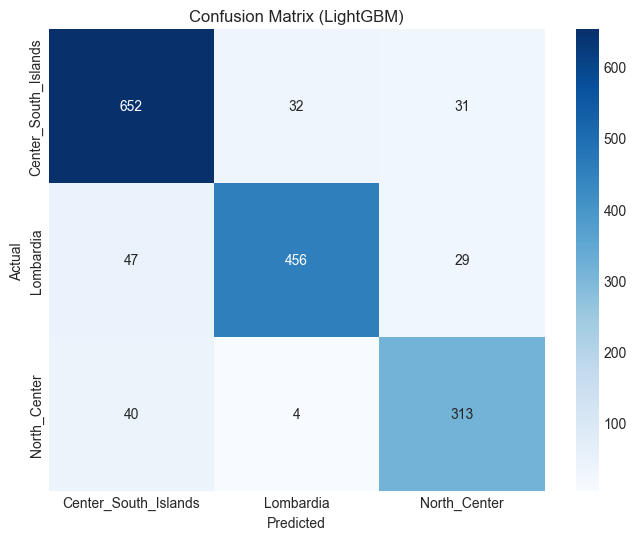

In [158]:
y_pred_best = best_model.predict(X_test)
print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Explainable AI (SHAP)

Understanding WHY the best model makes predictions.


<Figure size 1200x1000 with 0 Axes>

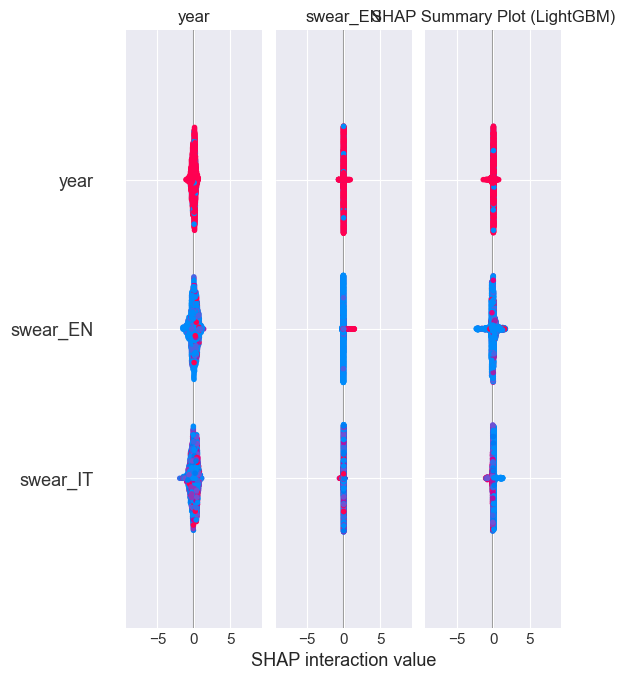

In [159]:
if best_model_name in ['XGBoost', 'LightGBM', 'RandomForest']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
else:
    explainer = shap.KernelExplainer(best_model.predict_proba, X_train[:100])
    shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, feature_names=X.columns, class_names=le_target.classes_, show=False)
plt.title(f'SHAP Summary Plot ({best_model_name})')
plt.show()


In [160]:
import random
idx = random.randint(0, len(X_test)-1)
sample_idx = idx 

sample_array = X_test[idx].reshape(1, -1)
prediction = best_model.predict(sample_array)[0]

sample_data = pd.DataFrame(sample_array, columns=X.columns)
actual = y_test[idx]
predicted_label = le_target.inverse_transform([prediction])[0]
actual_label = le_target.inverse_transform([actual])[0]

print(f"\nLocal Explanation for Song ID {sample_idx}")
print(f"Actual Macro-Zone:    {actual_label}")
print(f"Predicted Macro-Zone: {predicted_label}")

shap.initjs()
class_idx = int(prediction)

if isinstance(shap_values, list):
	shap_val_sample = shap_values[class_idx][idx]
	base_value = explainer.expected_value[class_idx]
elif len(shap_values.shape) == 3:
	shap_val_sample = shap_values[idx, :, class_idx]
	base_value = explainer.expected_value[class_idx]
else:
	shap_val_sample = shap_values[idx]
	base_value = explainer.expected_value

shap.force_plot(base_value, shap_val_sample, sample_data)


Local Explanation for Song ID 1554
Actual Macro-Zone:    North_Center
Predicted Macro-Zone: North_Center


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
